In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip = True,
    rotation_range = 10,
    brightness_range = [0.8, 1.2],
    zoom_range = 0.1
)

val_datagen = ImageDataGenerator(rescale = 1./255)

In [15]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'binary'   #normal = 0 and pneumonia = 1
)

Found 5216 images belonging to 2 classes.


In [16]:
val_gen = val_datagen.flow_from_directory(
    os.path.join(base_path, 'val'),
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
)

Found 16 images belonging to 2 classes.


In [17]:
test_gen = val_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 624 images belonging to 2 classes.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [19]:
model = Sequential([
    Conv2D(32, kernel_size = (3,3) , activation = 'relu', input_shape = (224,224,3)),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(64, kernel_size = (3,3) , activation = 'relu'),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer = 'adam',
            loss = 'binary_crossentropy',
            metrics = ['accuracy'])

In [22]:
hstory = model.fit(
    train_gen,
    epochs = 10,
    validation_data = val_gen,
    verbose = 1
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 939ms/step - accuracy: 0.8503 - loss: 0.5636 - val_accuracy: 0.8750 - val_loss: 0.3576
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 751ms/step - accuracy: 0.9187 - loss: 0.2098 - val_accuracy: 0.7500 - val_loss: 0.5430
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 749ms/step - accuracy: 0.9247 - loss: 0.2008 - val_accuracy: 0.6250 - val_loss: 0.7660
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 757ms/step - accuracy: 0.9291 - loss: 0.1874 - val_accuracy: 0.7500 - val_loss: 0.4203
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 744ms/step - accuracy: 0.9291 - loss: 0.1848 - val_accuracy: 0.7500 - val_loss: 0.5873
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 751ms/step - accuracy: 0.9392 - loss: 0.1583 - val_accuracy: 0.8125 - val_loss: 0.4553
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 744ms/step - accuracy: 0.9419 - loss: 0.1552 - val_accuracy: 0.8750 - val_loss: 0.3792
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 744ms/step - accuracy: 0.9385 -

In [27]:
print(f"Final Training Accuracy: {hstory.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {hstory.history['val_accuracy'][-1]:.4f}")

Final Training Accuracy: 0.9503
Final Validation Accuracy: 0.8750


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

test_gen.reset()
preds = (model.predict(test_gen) > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print(classification_report(true_labels, preds,
      target_names=['NORMAL', 'PNEUMONIA']))
print(confusion_matrix(true_labels, preds))

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 552ms/step
              precision    recall  f1-score   support

      NORMAL       0.94      0.56      0.70       234
   PNEUMONIA       0.79      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624

[[130 104]
 [  8 382]]


Text(0.5, 1.0, 'Confusion Matrix')

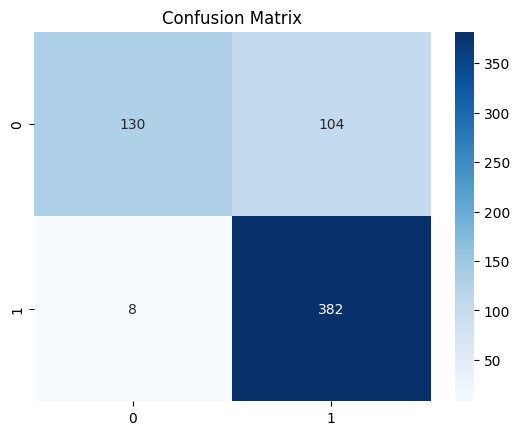

In [36]:
import seaborn as sns
sns.heatmap(confusion_matrix(true_labels,preds),annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')

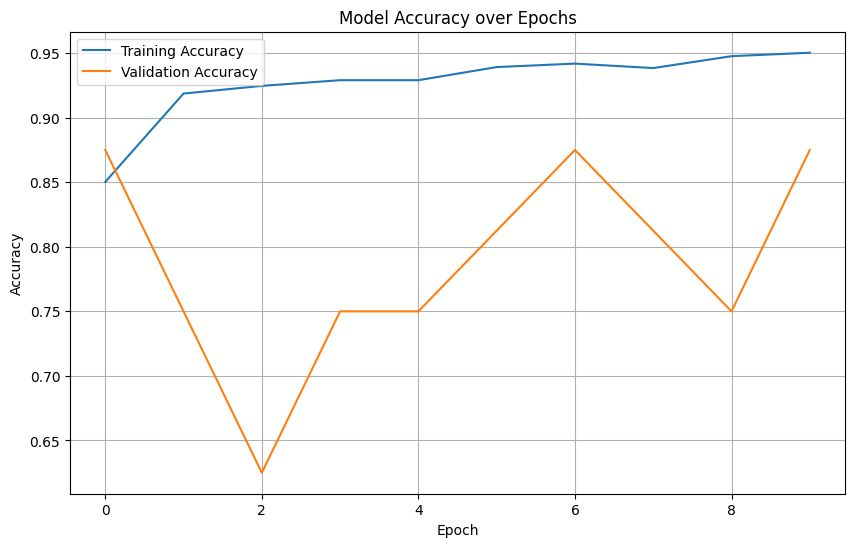

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(hstory.history['accuracy'], label='Training Accuracy')
plt.plot(hstory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
model.save('chest_xray_model.h5')